Instructions
Download and import the Data Science Job Salary dataset here.
Identify and differentiate between quantitative and qualitative data within the dataset.
Preprocess the data by handling missing values and removing duplicates if needed.
Perform a group-wise analysis of the experience_level column, calculating the mean and median salaries for each group using Pandas’ .groupby.
Utilize Pandas’ integration with Matplotlib to create a bar chart visualizing the average salaries for each experience level. Ensure the chart includes appropriate labels, a title, and a color scheme that enhances readability.


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
data_salary = pd.read_csv('ds_salaries.csv')
df =data_salary.copy()

In [29]:
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [30]:
df['experience_level'].unique()

array(['MI', 'SE', 'EN', 'EX'], dtype=object)

In [31]:
df.shape

(607, 12)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [33]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [34]:
df.columns.tolist()

['Unnamed: 0',
 'work_year',
 'experience_level',
 'employment_type',
 'job_title',
 'salary',
 'salary_currency',
 'salary_in_usd',
 'employee_residence',
 'remote_ratio',
 'company_location',
 'company_size']

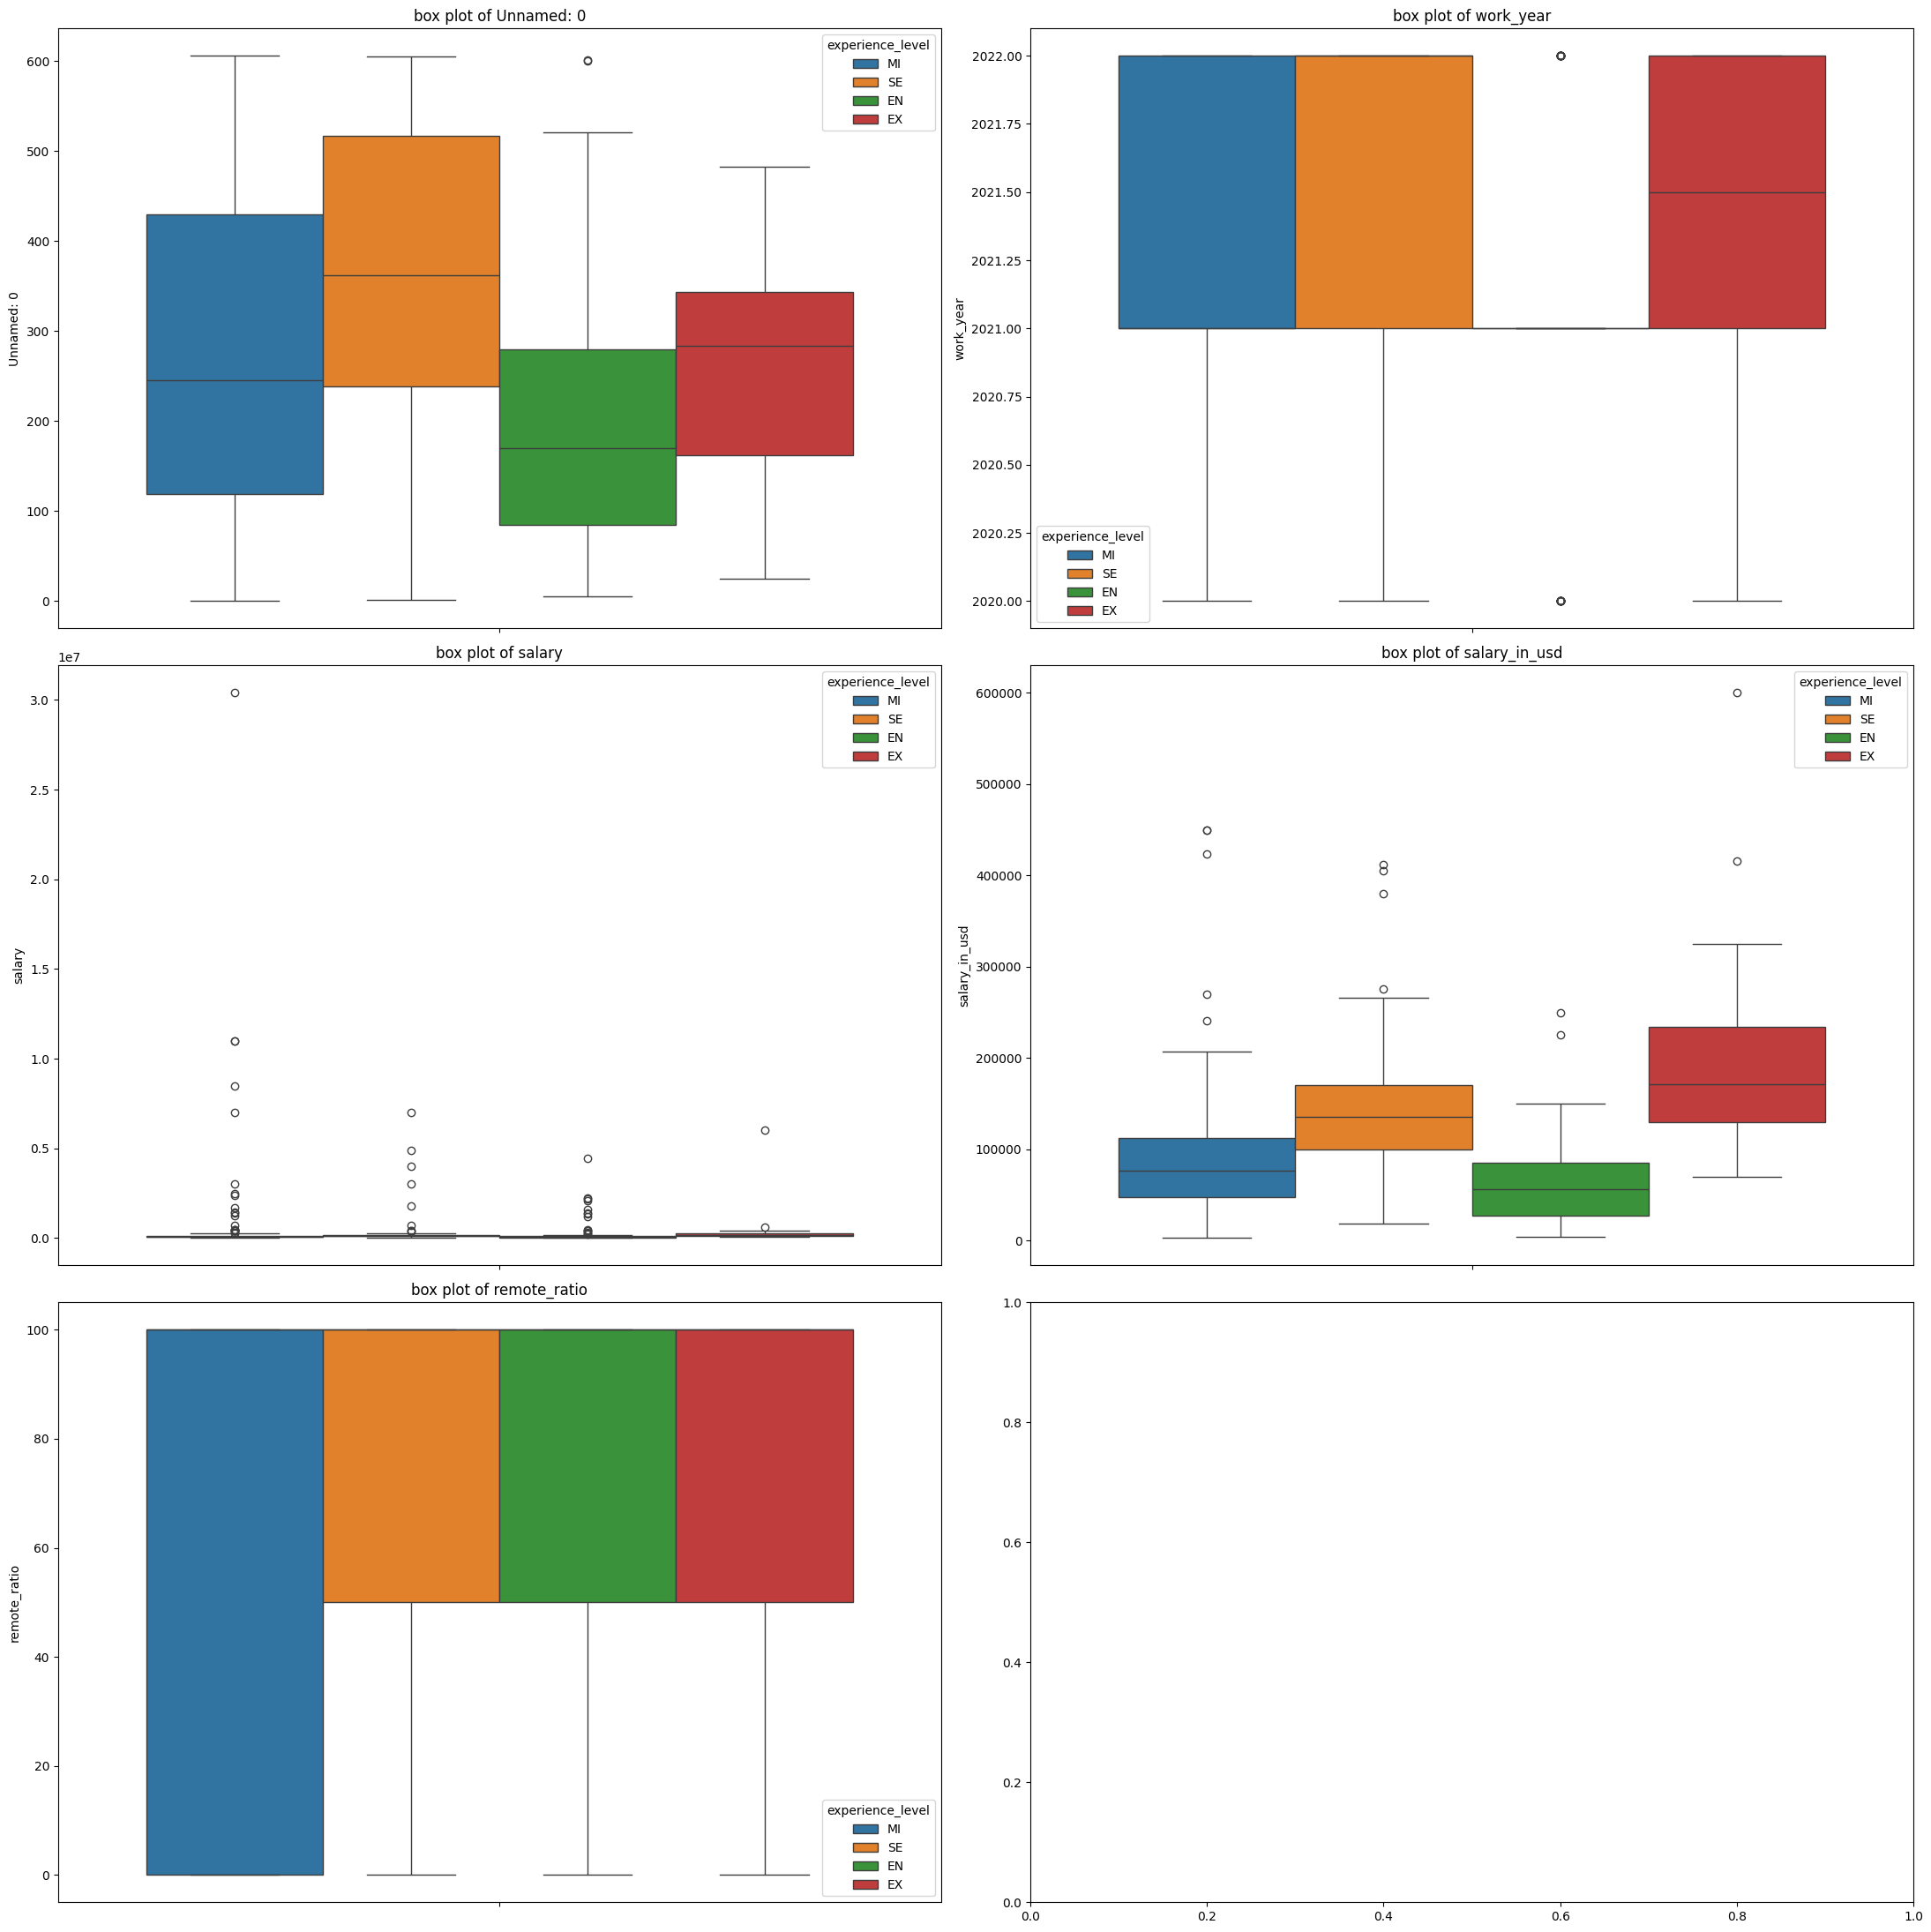

In [35]:
import seaborn as sns
figs, axes = plt.subplots(3, 2, figsize=(22,22))
cols =['Unnamed: 0', 'work_year', 'salary',	'salary_in_usd', 'remote_ratio']
for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(data=df, y = col, hue ='experience_level', ax =ax)
    ax.set_title(f'box plot of {col}')
plt.tight_layout()
plt.show()
    


In [36]:
from scipy import stats
df['zscore_salary'] = stats.zscore(df['salary'])

In [37]:
df['salary_no_outlier' ] = df[df['zscore_salary'] <3]['salary']
df['salary_no_outlier']

0       70000.0
1      260000.0
2       85000.0
3       20000.0
4      150000.0
         ...   
602    154000.0
603    126000.0
604    129000.0
605    150000.0
606    200000.0
Name: salary_no_outlier, Length: 607, dtype: float64

In [40]:
df['salary_no_outlier'].shape

(607,)

In [41]:
df.isna().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
zscore_salary         0
salary_no_outlier     7
dtype: int64

In [47]:
df = df.dropna(subset = 'salary_no_outlier')

<Axes: ylabel='salary_in_usd'>

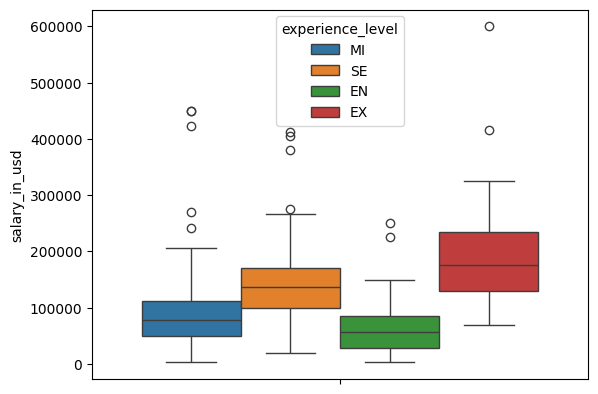

In [49]:
sns.boxplot(data =df, y ='salary_in_usd', hue = 'experience_level')

In [50]:
df['zscore_salary_usd'] = stats.zscore(df['salary_in_usd'])
df['salary_usd_no_outlier' ] = df[df['zscore_salary'] <3]['salary_in_usd']
df['salary_usd_no_outlier']

0       79833
1      260000
2      109024
3       20000
4      150000
        ...  
602    154000
603    126000
604    129000
605    150000
606    200000
Name: salary_usd_no_outlier, Length: 600, dtype: int64

In [51]:
df.isna().sum()

Unnamed: 0               0
work_year                0
experience_level         0
employment_type          0
job_title                0
salary                   0
salary_currency          0
salary_in_usd            0
employee_residence       0
remote_ratio             0
company_location         0
company_size             0
zscore_salary            0
salary_no_outlier        0
zscore_salary_usd        0
salary_usd_no_outlier    0
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(0)

In [55]:
avg_salary_experience = df.groupby('experience_level')['salary_no_outlier'].mean().round(2)
avg_salary_experience

experience_level
EN    264622.45
EX    204155.00
MI    165728.69
SE    189626.59
Name: salary_no_outlier, dtype: float64

In [63]:
avg_salary_experience_usd = df.groupby('experience_level')['salary_usd_no_outlier'].mean().round(2)
print(f'the average salary in $ for the various experience levels are:  {avg_salary_experience_usd}')

the average salary in $ for the various experience levels are:  experience_level
EN     61643.32
EX    204206.16
MI     88894.49
SE    138774.83
Name: salary_usd_no_outlier, dtype: float64


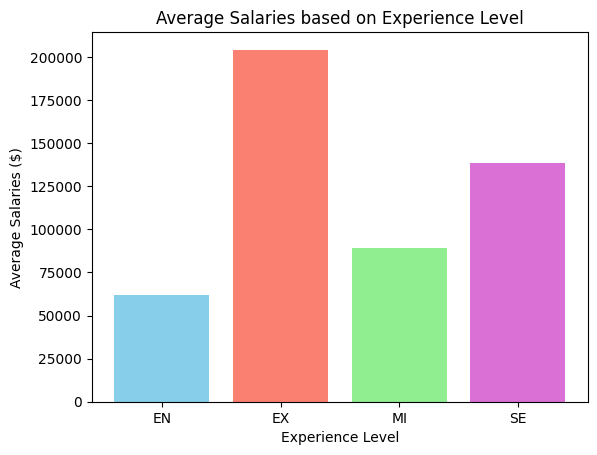

In [81]:

x_values = avg_salary_experience_usd.index
height_values = avg_salary_experience_usd.values
my_colors = ['skyblue', 'salmon', 'lightgreen', 'orchid']


plt.bar(x_values, height_values, color=my_colors)

plt.title('Average Salaries based on Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salaries ($)')

plt.show()